In [ ]:
!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list

ref                                                              title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
dmitriigluzdov/casmi26-pubchem-popularity-prior                  CASMI26 PubChem Popularity Prior                    1286771429  2026-10-05 02:40:35.677000           5372         48                1  
srisyra02/zomato-market-analysis                                 Restaurant Market Analysis: Ratings, Prices             444049  2026-09-17 17:02:06.437000           5343        110                1  
dreaddevelopment/raptor-knee-maxspan                             Knee MRI - Max-Span Dense Corpus                     271659195  2026-08-22 20:14:47.093000           1710         51           0.81

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
!kaggle datasets download -d venky73/spam-mails-dataset

Dataset URL: https://www.kaggle.com/datasets/venky73/spam-mails-dataset
License(s): CC0-1.0
100% 1.86M/1.86M [00:01<00:00, 1.79MB/s]



In [ ]:
!unzip -q spam-mails-dataset.zip -d spam-data/

In [ ]:
df=pd.read_csv('spam-data/spam_ham_dataset.csv')

In [ ]:
df.sample(5)

,Unnamed: 0,label,text,label_num
651,1541,ham,Subject: re : meter 984132 for 1 / 16 / 99\r\n...,0
3669,4419,spam,Subject: important auction info\r\nr 3 move\r\...,1
3635,2342,ham,Subject: hpl meter # 985225 freeport offshore ...,0
3910,2329,ham,Subject: maintenance work at meters 584 & 6040...,0
1630,4541,spam,Subject: hey !\r\nhi ! i am looking for new fr...,1


In [ ]:
updated_df=df.iloc[:, 1:]

In [ ]:
updated_df

,label,text,label_num
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,spam,"Subject: photoshop , windows , office . cheap ...",1
4,ham,Subject: re : indian springs\r\nthis deal is t...,0
...,...,...,...
5166,ham,Subject: put the 10 on the ft\r\nthe transport...,0
5167,ham,Subject: 3 / 4 / 2000 and following noms\r\nhp...,0
5168,ham,Subject: calpine daily gas nomination\r\n>\r\n...,0
5169,ham,Subject: industrial worksheets for august 2000...,0


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [22]:
df=pd.DataFrame(updated_df)

In [23]:
df

,label,text,label_num
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,spam,"Subject: photoshop , windows , office . cheap ...",1
4,ham,Subject: re : indian springs\r\nthis deal is t...,0
...,...,...,...
5166,ham,Subject: put the 10 on the ft\r\nthe transport...,0
5167,ham,Subject: 3 / 4 / 2000 and following noms\r\nhp...,0
5168,ham,Subject: calpine daily gas nomination\r\n>\r\n...,0
5169,ham,Subject: industrial worksheets for august 2000...,0


In [24]:
import seaborn as sns

In [26]:
df.describe()

,label_num
count,5171.000000
mean,0.289886
std,0.453753
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [32]:
df['label'].value_counts()

,count
label,
ham,3672
spam,1499


In [33]:
df['label'].isnull().sum()

np.int64(0)

In [37]:
df['text'].isnull().sum()

np.int64(0)

In [38]:
df['label_num'].isnull().sum()

np.int64(0)

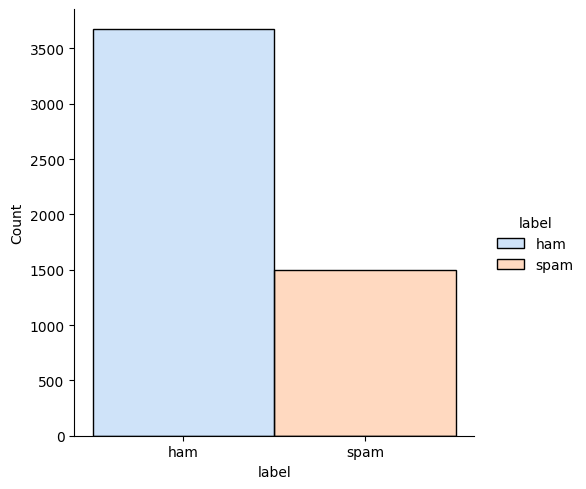

In [25]:
sns.displot(data=df, x="label", hue="label", palette="pastel")

In [39]:
pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.5 MB/s eta 0:00:00


In [40]:
pip install fg-data-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.5/400.5 kB 2.4 MB/s eta 0:00:00


In [41]:
from data_profiling import ProfileReport
profile = ProfileReport(df, title="Spam Data Profiling Report")

In [42]:
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 3/3 [00:01<00:00,  1.70it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [49]:
df_updated=df.drop_duplicates()

In [50]:
profile=ProfileReport(df_updated,title="SpamDatasetReport")

In [51]:
df_updated.duplicated().value_counts()

,count
False,4993


In [52]:
import matplotlib.pyplot as plt

In [73]:
encoded_labels = pd.get_dummies(df_updated['label'], prefix='label',dtype=int)

In [74]:
encoded_labels.sample(10)

,label_ham,label_spam
4309,1,0
4155,1,0
2670,0,1
534,0,1
2607,1,0
2198,1,0
2101,1,0
95,1,0
4522,0,1
2865,1,0


In [75]:
final_encoded = pd.get_dummies(df_updated['label'], prefix='label', drop_first=True, dtype=int)

In [76]:
final_encoded.sample(10)

,label_spam
1723,0
275,0
4988,0
1533,0
5145,0
2935,0
1083,1
3789,1
1091,0
2998,0


## One Hot Encoding
i did one-hot encoding on the label column where the out was like spam or ham so i use the one endoing and avoid the multi-colinearity from which that data become confues if the columns is so many so for that we remove the first column for every rows.

## Important tip
YOu should do the one hot encoding on the label columns and then the train test split and then do the vecotrization bcz it is the most market and suitable technique to avoid the data leakage

In [77]:
from sklearn.model_selection import train_test_split

x=df_updated['text']
y=final_encoded['label_spam']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Splitting Successfully!")
print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)
print("Y_train shape:", y_train.shape)
print("Y_test shape:", y_test.shape)

Splitting Successfully!
X_train shape: (3994,)
X_test shape: (999,)
Y_train shape: (3994,)
Y_test shape: (999,)


## Vectorization

In [78]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')
x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

In [79]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

model = MultinomialNB()

model.fit(x_train_tfidf, y_train)

MultinomialNB()

In [82]:
y_predict= model.predict(x_test_tfidf)

In [84]:
accuracy=accuracy_score(y_test,y_predict)

In [85]:
accuracy

0.9279279279279279

In [86]:
print(classification_report(y_test,y_predict,target_names=['ham','spam']))

              precision    recall  f1-score   support

         ham       0.91      1.00      0.95       732
        spam       0.99      0.73      0.84       267

    accuracy                           0.93       999
   macro avg       0.95      0.87      0.90       999
weighted avg       0.93      0.93      0.92       999

